In [1]:
import pandas as pd
import torch

import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
#biocomplexity/fa7sa/Diffusion_multi_step/without_ADM_output

In [15]:
epoch = 1

## path for diffusion with Einc as condition and all 45 layers together
gen_path_main = f'/project/biocomplexity/fa7sa/Diffusion_multi_step/without_ADM_output'
ref_path_main = f'/project/biocomplexity/fa7sa/Diffusion_multi_step/without_ADM_output'
file_suffix = '_wo_ADM'
max_epoch = 20

## path for diffusion with Einc as condition and sampling x~[0,45] layer during training
gen_path_main = f'/project/biocomplexity/fa7sa/Diffusion_multi_step/autoregressive-diffusion-pytorch/transformer_output/'
ref_path_main = f'/project/biocomplexity/fa7sa/Diffusion_multi_step/autoregressive-diffusion-pytorch/transformer_output/'
file_suffix = '_embed_128'
max_epoch = 100
#generated = torch.load(gen_path)
#reference = torch.load(ref_path)

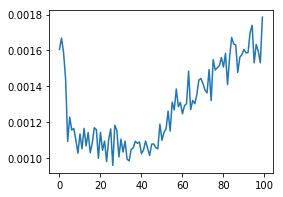

In [17]:
import numpy as np

import matplotlib.pyplot as plt

xs = []
ys = []

for epoch in range(0,max_epoch):
    #epoch = epochs[idx]
    #sample_no = sample_nos[idx]

    gen_path = f'{gen_path_main}/generated{file_suffix}_{epoch}.pt'
    ref_path = f'{ref_path_main}/reference{file_suffix}_{epoch}.pt'

    generated = torch.load(gen_path)
    reference = torch.load(ref_path)
    
    gen_sample = np.array(generated[:,:,0])
    ref_sample = np.array(reference[:,:,0])
    
    #print(gen_sample.shape, ref_sample.shape)
    
    mses = ((gen_sample-ref_sample)**2).mean(axis=1)
    #print(epoch, mses.mean())
    xs.append(epoch)
    ys.append(mses.mean())
fig,ax = plt.subplots(figsize=(4,3))
ax.plot(xs,ys)


In [21]:
def find_sample_in_epoch_data(epoch,single_sample):
    
    gen_path = f'{gen_path_main}/generated{file_suffix}_{epoch}.pt'
    ref_path = f'{ref_path_main}/reference{file_suffix}_{epoch}.pt'
    
    reference = torch.load(ref_path)
    ii = 0
    for cur_sample in reference:
        if (single_sample==cur_sample[:,0]).all():
            return ii
        ii = ii+1
    return -1

epochs = [0]
sample_nos = [333]

ref_path = f'{ref_path_main}/reference{file_suffix}_{epochs[0]}.pt'
reference = torch.load(ref_path)

for sample_idx in range(sample_nos[0],sample_nos[0]+1):
    found = 0
    ref_sample = reference[sample_idx,:,0]
    for e in range(1,max_epoch):
        another_epoch_sample = find_sample_in_epoch_data(e,ref_sample)
        if another_epoch_sample!=-1:
            print(f'sample {sample_idx} of epoch {epochs[0]} was also found in sample {another_epoch_sample} of epoch {e}')
            epochs.append(e)
            sample_nos.append(another_epoch_sample)
            found = found+1
    print(found)

sample 333 of epoch 0 was also found in sample 587 of epoch 15
sample 333 of epoch 0 was also found in sample 474 of epoch 17
sample 333 of epoch 0 was also found in sample 749 of epoch 20
sample 333 of epoch 0 was also found in sample 881 of epoch 27
sample 333 of epoch 0 was also found in sample 331 of epoch 29
sample 333 of epoch 0 was also found in sample 168 of epoch 35
sample 333 of epoch 0 was also found in sample 616 of epoch 43
sample 333 of epoch 0 was also found in sample 203 of epoch 55
sample 333 of epoch 0 was also found in sample 603 of epoch 56
sample 333 of epoch 0 was also found in sample 353 of epoch 58
sample 333 of epoch 0 was also found in sample 928 of epoch 74
sample 333 of epoch 0 was also found in sample 785 of epoch 81
sample 333 of epoch 0 was also found in sample 313 of epoch 88
sample 333 of epoch 0 was also found in sample 391 of epoch 95
14


In [25]:
def visualize_energy_sample(ax,idx,epochs,sample_nos):
    
    epoch = epochs[idx]
    sample_no = sample_nos[idx]

    gen_path = f'{gen_path_main}/generated{file_suffix}_{epoch}.pt'
    ref_path = f'{ref_path_main}/reference{file_suffix}_{epoch}.pt'

    generated = torch.load(gen_path)
    reference = torch.load(ref_path)

    gen_sample = generated[sample_no,:,0]
    ref_sample = reference[sample_no,:,0]
    #print(ref_sample[0:5])

    layers = [i for i in range(generated.shape[1])]

    mse = ((ref_sample - gen_sample) ** 2).mean()
    rmse = mse**0.5
    nrmse = rmse/(ref_sample.max()-ref_sample.min())
    print(f'MSE {round(mse.item(),2)}, RMSE {round(rmse.item(),2)}, Normalized Error {round(nrmse.item()*100,2)} % at epoch {epoch}')
    
    ax.plot(layers,gen_sample,label='model')
    ax.plot(layers,ref_sample,label='geant4',color='red')
    
    ax.legend(loc='best')
    ax.set_xlabel('Layer')
    ax.set_ylabel('Layer Energy')
    ax.set_title(f'Sample-{sample_no} of Epoch {epoch}')
    #ax.set_ylim([-0.14,-0.02])

In [23]:
len(epochs)

15

MSE 0.0, RMSE 0.02, Normalized Error 35.97 % at epoch 0
MSE 0.0, RMSE 0.01, Normalized Error 22.14 % at epoch 15
MSE 0.0, RMSE 0.01, Normalized Error 21.7 % at epoch 17
MSE 0.0, RMSE 0.01, Normalized Error 20.77 % at epoch 20
MSE 0.0, RMSE 0.01, Normalized Error 23.56 % at epoch 27
MSE 0.0, RMSE 0.01, Normalized Error 23.21 % at epoch 29
MSE 0.0, RMSE 0.01, Normalized Error 22.15 % at epoch 35
MSE 0.0, RMSE 0.01, Normalized Error 19.03 % at epoch 43
MSE 0.0, RMSE 0.01, Normalized Error 14.91 % at epoch 55
MSE 0.0, RMSE 0.01, Normalized Error 16.5 % at epoch 56
MSE 0.0, RMSE 0.01, Normalized Error 16.04 % at epoch 58
MSE 0.0, RMSE 0.01, Normalized Error 14.73 % at epoch 74
MSE 0.0, RMSE 0.01, Normalized Error 18.38 % at epoch 81
MSE 0.0, RMSE 0.01, Normalized Error 20.78 % at epoch 88
MSE 0.0, RMSE 0.01, Normalized Error 20.74 % at epoch 95


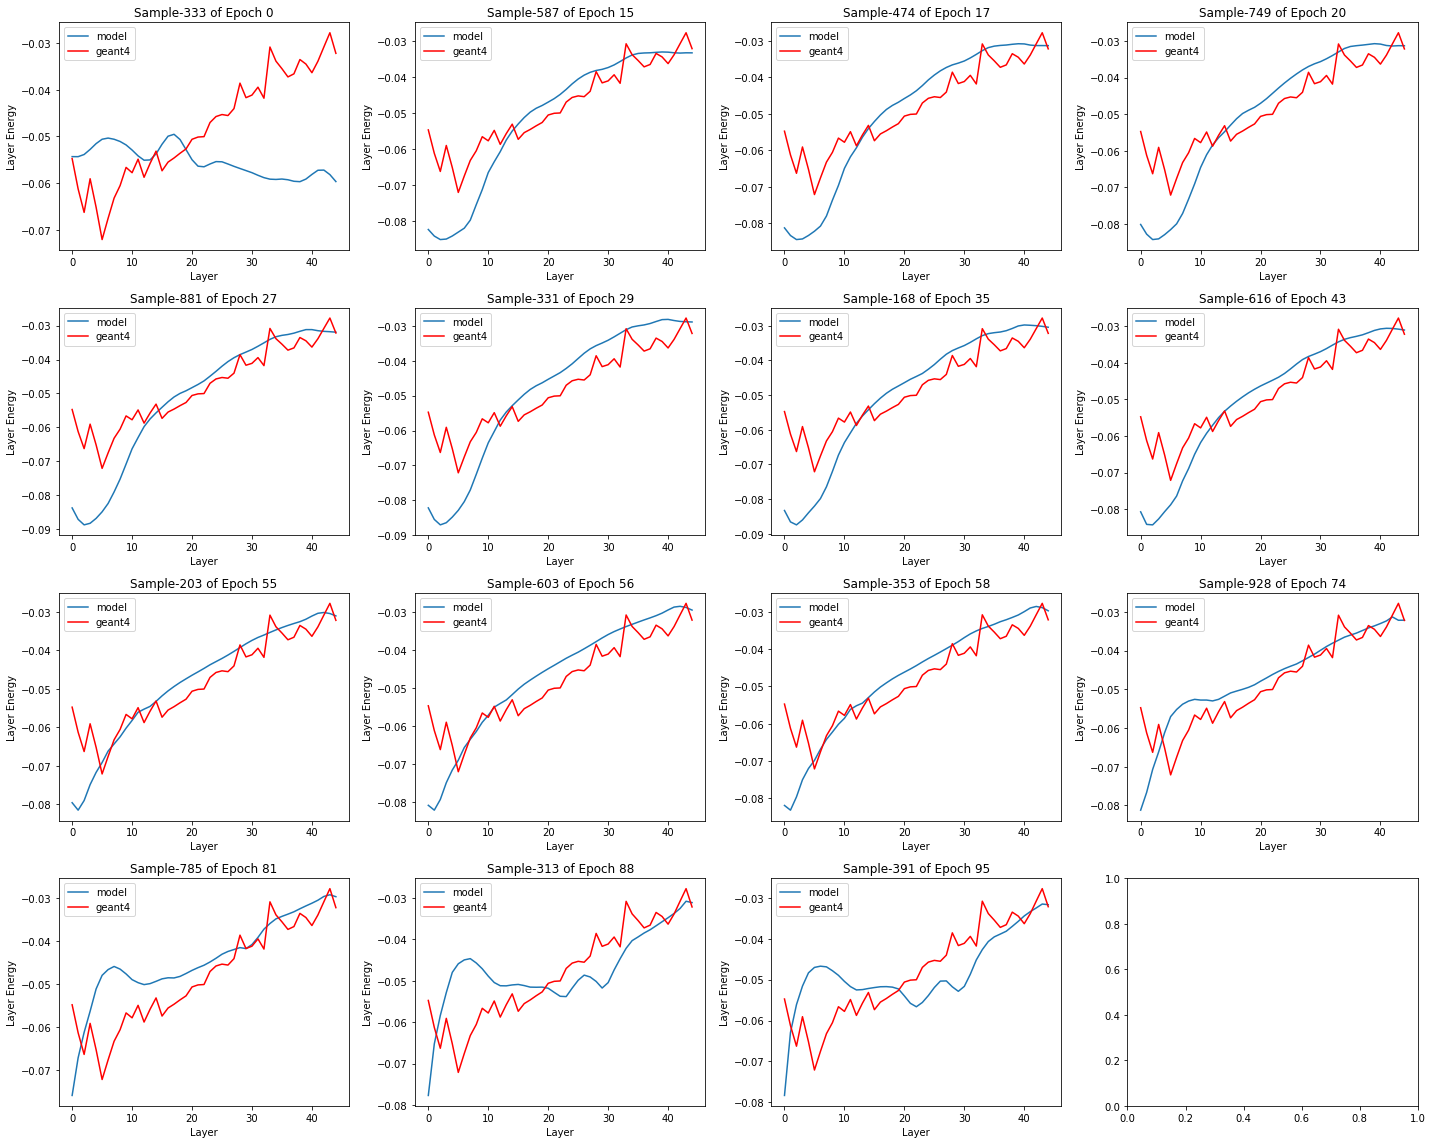

In [26]:
row = 4
col = 4

fig,ax = plt.subplots(row,col,figsize=(5*row,4*col))

for idx in range(len(epochs)):
    visualize_energy_sample(ax[idx//col][idx%col],idx,epochs,sample_nos)

fig.tight_layout()